In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [2]:
# =====================================================
# PREPROCESSING
# =====================================================

def PreProcessing(image, kernel_size=3):

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size)
    )

    image = cv2.morphologyEx(
        image,
        cv2.MORPH_OPEN,
        kernel
    )

    return image

In [3]:
# =====================================================
# WATERSHED NUCLEI SEGMENTATION
# =====================================================

def SegmentNucleiWatershed(
        dapi_channel,
        threshold_value):

    _, binary = cv2.threshold(
        dapi_channel,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    kernel = np.ones((3,3), np.uint8)

    opening = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel,
        iterations=2
    )

    sure_bg = cv2.dilate(
        opening,
        kernel,
        iterations=3
    )

    dist = cv2.distanceTransform(
        opening,
        cv2.DIST_L2,
        5
    )

    _, sure_fg = cv2.threshold(
        dist,
        0.35*dist.max(),
        255,
        0
    )

    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(
        sure_bg,
        sure_fg
    )

    num_labels, markers = cv2.connectedComponents(
        sure_fg
    )

    markers = markers + 1

    markers[unknown == 255] = 0

    color_image = cv2.cvtColor(
        dapi_channel,
        cv2.COLOR_GRAY2RGB
    )

    markers = cv2.watershed(
        color_image,
        markers
    )

    return markers, binary

In [4]:
# =====================================================
# NFKB ANALYSIS
# =====================================================

def NFKB_Nuclear_Analysis(
        image,
        dapi_threshold,
        nfkb_threshold,
        output_dir,
        filename):

    red = image[:,:,0]
    blue = image[:,:,2]

    markers, nuclei_mask = SegmentNucleiWatershed(
        blue,
        dapi_threshold
    )

    _, nfkb_mask = cv2.threshold(
        red,
        nfkb_threshold,
        255,
        cv2.THRESH_BINARY
    )

    nuclear_nfkb_mask = cv2.bitwise_and(
        nuclei_mask,
        nfkb_mask
    )

    unique_labels = np.unique(markers)

    total_nuclei = 0
    positive_nuclei = 0

    positive_contours = []
    negative_contours = []

    overlay = image.copy()

    for label in unique_labels:

        if label <= 1:
            continue

        nucleus = np.zeros(
            markers.shape,
            dtype=np.uint8
        )

        nucleus[markers == label] = 255

        nucleus_area = np.sum(
            nucleus > 0
        )

        if nucleus_area < 50:
            continue

        total_nuclei += 1

        overlap = cv2.bitwise_and(
            nucleus,
            nfkb_mask
        )

        overlap_area = np.sum(
            overlap > 0
        )

        if overlap_area > 10:

            positive_nuclei += 1

            contours, _ = cv2.findContours(
                nucleus,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            positive_contours.extend(contours)

        else:

            contours, _ = cv2.findContours(
                nucleus,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            negative_contours.extend(contours)

    total_nuclear_area = np.sum(
        nuclei_mask > 0
    )

    nuclear_nfkb_area = np.sum(
        nuclear_nfkb_mask > 0
    )

    positive_percentage = (
        positive_nuclei /
        total_nuclei *
        100
        if total_nuclei > 0
        else 0
    )

    nuclear_area_percentage = (
        nuclear_nfkb_area /
        total_nuclear_area *
        100
        if total_nuclear_area > 0
        else 0
    )

    cv2.drawContours(
        overlay,
        negative_contours,
        -1,
        (0,255,255),
        2
    )

    cv2.drawContours(
        overlay,
        positive_contours,
        -1,
        (255,0,0),
        2
    )

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("NFκB positive nuclei")
    plt.axis('off')

    plt.savefig(
        os.path.join(
            output_dir,
            f"{filename}_positive_nuclei.png"
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.figure(figsize=(8,8))
    plt.imshow(nuclear_nfkb_mask,
               cmap='gray')
    plt.title("NFκB inside nuclei")
    plt.axis('off')

    plt.savefig(
        os.path.join(
            output_dir,
            f"{filename}_nuclear_NFKB_mask.png"
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print()
    print("=================================")
    print("TOTAL NUCLEI =", total_nuclei)
    print("NFKB+ NUCLEI =", positive_nuclei)
    print("% NFKB+ NUCLEI =", positive_percentage)
    print("TOTAL NUCLEAR AREA =", total_nuclear_area)
    print("NUCLEAR NFKB AREA =", nuclear_nfkb_area)
    print("% NUCLEAR NFKB AREA =", nuclear_area_percentage)
    print("=================================")

    return {
        "Total_Nuclei": total_nuclei,
        "Positive_Nuclei": positive_nuclei,
        "Positive_Nuclei_Percentage": positive_percentage,
        "Nuclear_Area": total_nuclear_area,
        "Nuclear_NFKB_Area": nuclear_nfkb_area,
        "Nuclear_NFKB_Percentage": nuclear_area_percentage
    }

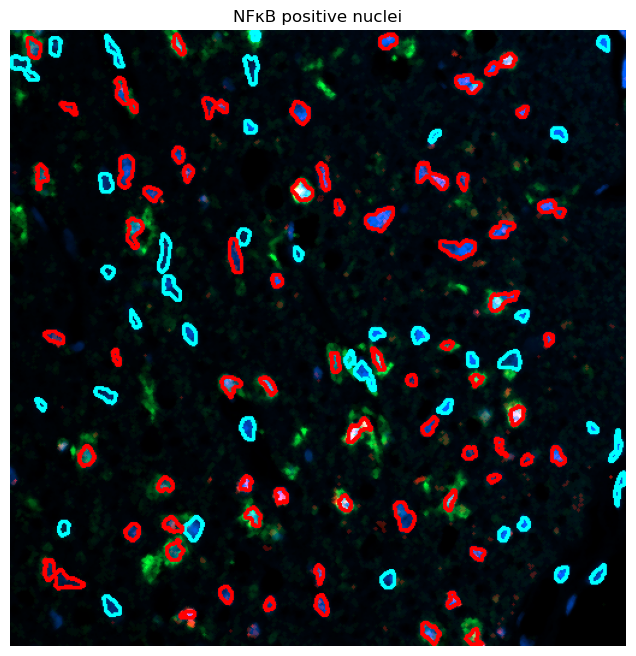

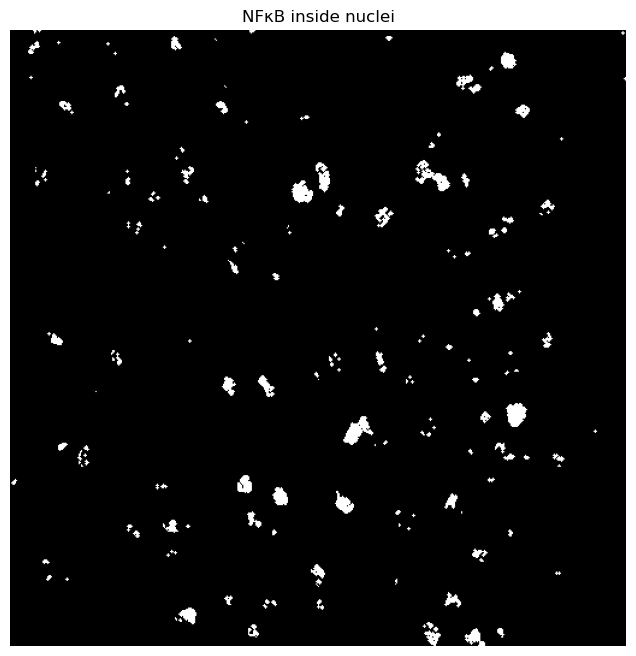


TOTAL NUCLEI = 106
NFKB+ NUCLEI = 67
% NFKB+ NUCLEI = 63.20754716981132
TOTAL NUCLEAR AREA = 24636
NUCLEAR NFKB AREA = 5362
% NUCLEAR NFKB AREA = 21.764896898847216
{'Total_Nuclei': 106, 'Positive_Nuclei': 67, 'Positive_Nuclei_Percentage': 63.20754716981132, 'Nuclear_Area': 24636, 'Nuclear_NFKB_Area': 5362, 'Nuclear_NFKB_Percentage': 21.764896898847216}


In [5]:

# =====================================================
# MAIN
# =====================================================

path = r"G:\Mi unidad\Doctorado\1 TRATAMIENTOS\FTY720\Inmuno\1D\TRANSVERSAL\NFKB nueva alicuota\LPS F\2 od\3\m all.tif"

output_dir = os.path.dirname(path)
filename = os.path.splitext(
    os.path.basename(path)
)[0]

image = cv2.imread(path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

processed = PreProcessing(
    image,
    kernel_size=3
)

results = NFKB_Nuclear_Analysis(
    processed,
    dapi_threshold=40,
    nfkb_threshold=40,
    output_dir=output_dir,
    filename=filename
)

print(results)